# 02 - Data Preprocessing and Data Pipeline

## Objectives

The objective of this notebook is to design and implement a robust data preprocessing pipeline for the LEVIR-CD dataset. The preprocessing stage ensures that the satellite images and corresponding binary masks are transformed into a format suitable for deep learning models.

The specific objectives are:

- Develop a custom PyTorch Dataset class for loading paired satellite images and ground truth masks.
- Apply image preprocessing techniques required for model training.
- Compute and apply image normalization using the previously obtained RGB statistics.
- Implement data augmentation techniques to improve model generalization.
- Create efficient DataLoader objects for the training, validation, and testing datasets.
- Verify the correctness of preprocessing through visual inspection of transformed samples.
- Establish a reusable data pipeline for all subsequent deep learning experiments.

In [12]:
import os
import random
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms

import albumentations as A
from albumentations.pytorch import ToTensorV2

In [13]:
DATASET_PATH = "../data/"

TRAIN_PATH = os.path.join(DATASET_PATH, "train")
VAL_PATH = os.path.join(DATASET_PATH, "val")
TEST_PATH = os.path.join(DATASET_PATH, "test")

In [14]:
IMAGE_SIZE = 1024

BATCH_SIZE = 4

NUM_WORKERS = 0

PIN_MEMORY = True

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device :", DEVICE)

Device : cuda


In [15]:
MEAN = [0.45026043, 0.44666810, 0.38134657]

STD = [0.19258917, 0.18164736, 0.16908678]

In [16]:
train_transform = A.Compose([
    
    A.HorizontalFlip(p=0.5),
    
    A.VerticalFlip(p=0.5),
    
    A.RandomRotate90(p=0.5),
    
    A.Normalize(mean=MEAN, std=STD),
    
    ToTensorV2()

])

In [17]:
val_transform = A.Compose([
    
    A.Normalize(mean=MEAN, std=STD),
    
    ToTensorV2()

])

In [18]:
class LEVIRDataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.root_dir = Path(root_dir)

        self.transform = transform

        self.a_images = sorted((self.root_dir / "A").glob("*"))

        self.b_images = sorted((self.root_dir / "B").glob("*"))

        self.labels = sorted((self.root_dir / "label").glob("*"))


    def __len__(self):

        return len(self.a_images)


    def __getitem__(self, index):

        before = np.array(Image.open(self.a_images[index]).convert("RGB"))

        after = np.array(Image.open(self.b_images[index]).convert("RGB"))

        mask = np.array(Image.open(self.labels[index]))

        mask = (mask > 0).astype(np.float32)

        if self.transform:

            transformed_before = self.transform(image=before)

            transformed_after = self.transform(image=after)

            before = transformed_before["image"]

            after = transformed_after["image"]

            mask = torch.tensor(mask, dtype=torch.float32)

        return before, after, mask

In [19]:
train_dataset = LEVIRDataset(TRAIN_PATH, transform=train_transform)

val_dataset = LEVIRDataset(VAL_PATH, transform=val_transform)

test_dataset = LEVIRDataset(TEST_PATH, transform=val_transform)

In [20]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

In [21]:
before, after, mask = next(iter(train_loader))

print("Before :", before.shape)

print("After :", after.shape)

print("Mask :", mask.shape)

Before : torch.Size([4, 3, 1024, 1024])
After : torch.Size([4, 3, 1024, 1024])
Mask : torch.Size([4, 1024, 1024])


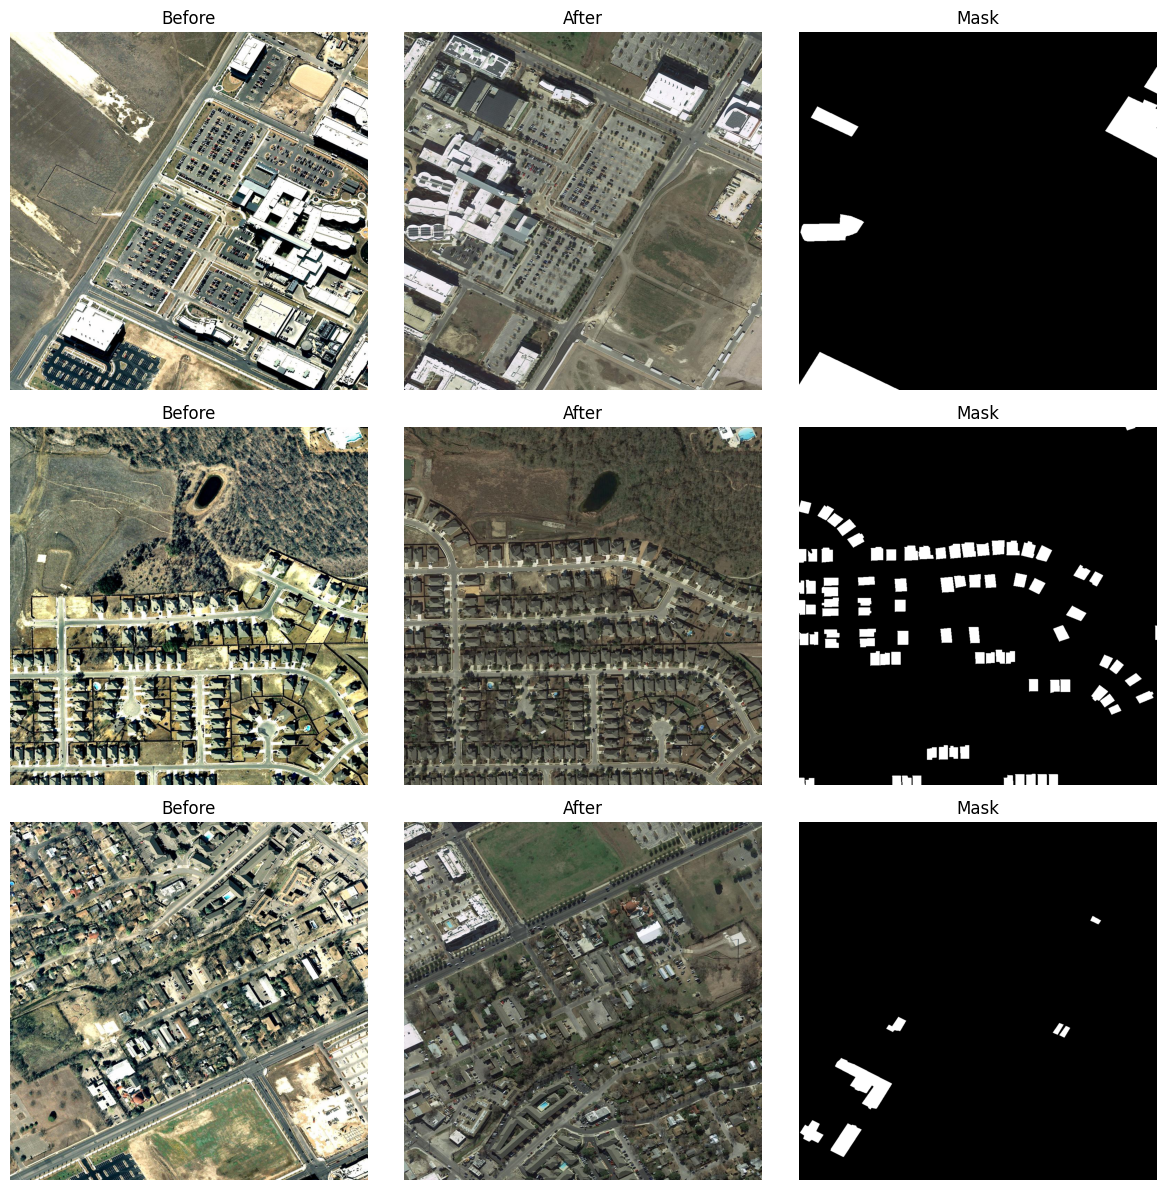

In [23]:
before, after, mask = next(iter(train_loader))

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i in range(3):

    b = before[i].permute(1, 2, 0).numpy()
    a = after[i].permute(1, 2, 0).numpy()
    m = mask[i].numpy()

    # Undo normalization for display
    b = b * STD + MEAN
    a = a * STD + MEAN

    b = np.clip(b, 0, 1)
    a = np.clip(a, 0, 1)

    axes[i, 0].imshow(b)
    axes[i, 0].set_title("Before")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(a)
    axes[i, 1].set_title("After")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(m, cmap="gray")
    axes[i, 2].set_title("Mask")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

# Observations

The preprocessing pipeline was successfully implemented and validated for the LEVIR-CD dataset.

## Key Observations

- A custom PyTorch Dataset class successfully loads paired pre-change and post-change satellite images along with their corresponding binary masks.
- Dataset-specific RGB normalization was applied using the computed channel statistics, ensuring consistent input distribution for model training.
- Data augmentation techniques were integrated into the training pipeline to improve model robustness and reduce overfitting.
- DataLoader objects correctly generate mini-batches for the training, validation, and testing datasets.
- Batch verification confirmed that the tensor dimensions are:
  - Image A: `(Batch Size, 3, 1024, 1024)`
  - Image B: `(Batch Size, 3, 1024, 1024)`
  - Mask: `(Batch Size, 1024, 1024)`
- Visualization of transformed samples confirms that the preprocessing pipeline preserves image quality and correctly prepares the data for deep learning models.

## Conclusion

The preprocessing pipeline is complete and provides an efficient framework for loading, transforming, and batching the LEVIR-CD dataset. This pipeline establishes the foundation for implementing and training the baseline change detection model in the subsequent phase of the project.